# Ramsey's RESET Test For Misspecification 

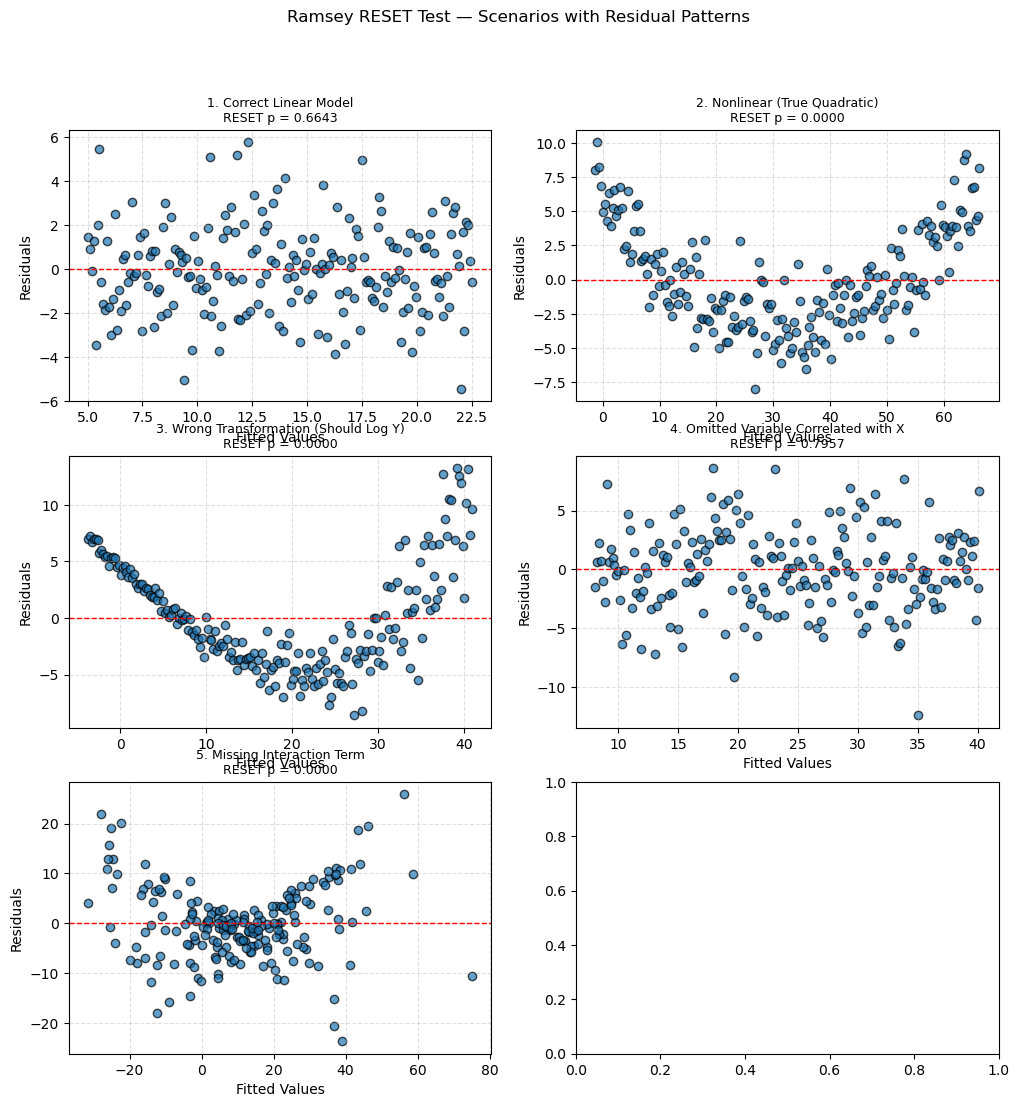

In [6]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import linear_reset

n = 200
X1 = np.linspace(1, 10, n)
X2 = np.random.normal(0, 1, n)

def run_reset_and_plot(Y, X, name, ax):
    X_ = sm.add_constant(X)
    model = sm.OLS(Y, X_).fit()
    reset = linear_reset(model, power=2, use_f=True)
    fitted = model.fittedvalues
    residuals = model.resid

    ax.scatter(fitted, residuals, alpha=0.7, edgecolor='k')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{name}\nRESET p = {reset.pvalue:.4f}", fontsize=9)
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Residuals")
    ax.grid(True, linestyle="--", alpha=0.4)

    return reset.pvalue

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

#Correct linear model
Y1 = 3 + 2*X1 + np.random.normal(0, 2, n)
run_reset_and_plot(Y1, X1, "1. Correct Linear Model", axes[0])

#Nonlinear (true quadratic)
Y2 = 3 + 2*X1 + 0.5*X1**2 + np.random.normal(0, 2, n)
run_reset_and_plot(Y2, X1, "2. Nonlinear (True Quadratic)", axes[1])

#Wrong transformation (should be log of Y)
Y3 = np.exp(1 + 0.3*X1 + np.random.normal(0, 0.1, n))
run_reset_and_plot(Y3, X1, "3. Wrong Transformation (Should Log Y)", axes[2])

#Omitted variable correlated with included X
Z = 0.5*X1 + np.random.normal(0, 1, n)
Y4 = 5 + 2*X1 + 3*Z + np.random.normal(0, 2, n)
run_reset_and_plot(Y4, X1, "4. Omitted Variable Correlated with X", axes[3])

#Missing interaction term
Y5 = 2 + 1.5*X1 + 2*X2 + 3*(X1*X2) + np.random.normal(0, 2, n)
X_base = np.column_stack([X1, X2])
run_reset_and_plot(Y5, X_base, "5. Missing Interaction Term", axes[4])


plt.suptitle("Ramsey RESET Test — Scenarios with Residual Patterns")
plt.tight_layout
plt.show()